In [1]:
# ========== 环境准备 ==========
import warnings                          # 导入警告控制模块
warnings.filterwarnings('ignore')  # 隐藏无关警告

import numpy as np              # 数值计算
import pandas as pd             # 表格数据
import matplotlib.pyplot as plt   # 画图
import yfinance as yf # 下载股票行情（需联网）
import akshare as ak                      # 从国内数据源下载 A 股行情

plt.rcParams['font.sans-serif'] = ['SimHei']   # 图表中文
plt.rcParams['axes.unicode_minus'] = False    # 负号正常

TICKER = 'AAPL'   # 股票代码，可改成 TSLA、NVDA
PERIOD = '2y'     # 下载多长历史（均线需要足够天数）

print('环境就绪 ✓')                       # 提示：环境加载完成


环境就绪 ✓


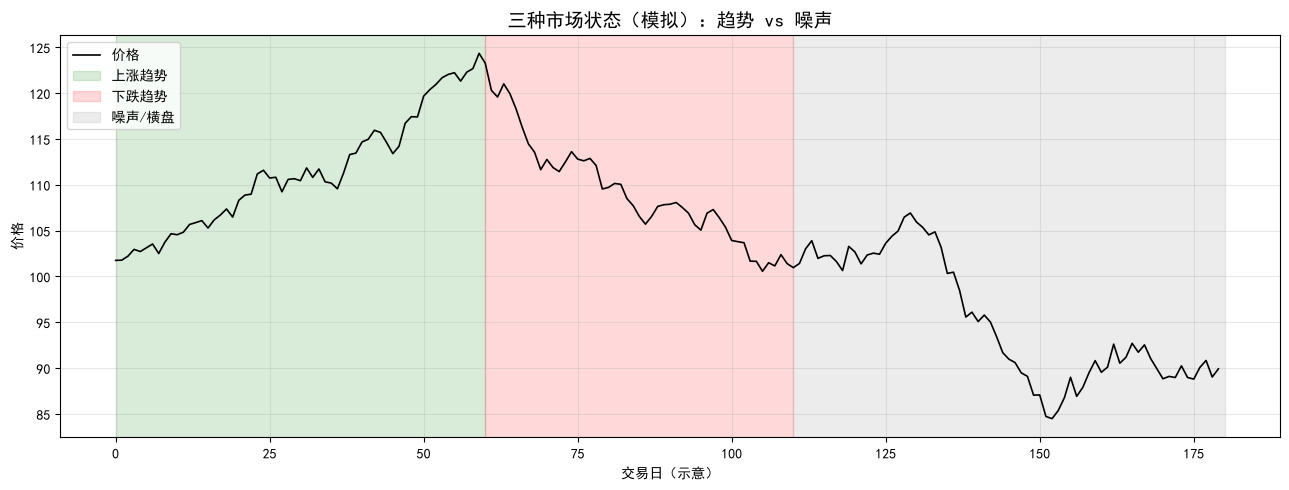

绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大


In [2]:
# ========== 模拟三种市场状态并分区上色 ==========
np.random.seed(7)              # 固定随机数，图可复现
n_up, n_down, n_noise = 60, 50, 70  # 上涨段、下跌段、横盘段各多少天

ret_up = np.random.normal(0.004, 0.008, n_up)        # 上涨段：平均日收益偏正
ret_down = np.random.normal(-0.005, 0.010, n_down)   # 下跌段：平均日收益偏负
ret_noise = np.random.normal(0.0, 0.015, n_noise)    # 横盘：均值约0，波动大

price = 100 * np.cumprod(1 + np.r_[ret_up, ret_down, ret_noise])  # 拼成价格
x = np.arange(len(price))  # 横轴：第几个交易日

fig, ax = plt.subplots(figsize=(13, 5))  # 创建子图
ax.plot(x, price, color='black', linewidth=1.2, label='价格')  # 在子图上画折线

ax.axvspan(0, n_up, alpha=0.15, color='green', label='上涨趋势')  # 用色块标出区间
ax.axvspan(n_up, n_up + n_down, alpha=0.15, color='red', label='下跌趋势')  # 用色块标出区间
ax.axvspan(n_up + n_down, len(price), alpha=0.15, color='gray', label='噪声/横盘')  # 用色块标出区间

ax.set_title('三种市场状态（模拟）：趋势 vs 噪声', fontsize=14)  # 设置子图标题
ax.set_xlabel('交易日（示意）')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend(loc='upper left')  # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('market_states_demo.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片

print('绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大')  # 解读三色区域含义


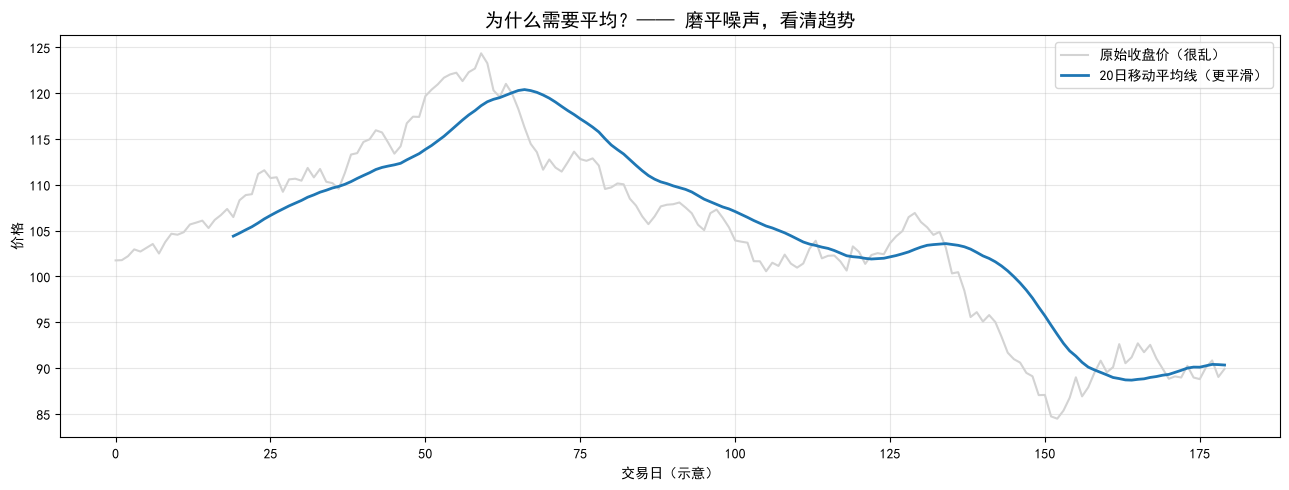

In [3]:
# ========== 对比「乱的价格」和「平滑的均线」==========
demo = pd.DataFrame({'Close': price})           # 用上面模拟的价格
demo['MA20'] = demo['Close'].rolling(20).mean()  # 20日移动平均

fig, ax = plt.subplots(figsize=(13, 5))  # 创建子图
ax.plot(demo['Close'], label='原始收盘价（很乱）', color='lightgray', linewidth=1.5)  # 在子图上画折线
ax.plot(demo['MA20'], label='20日移动平均线（更平滑）', color='tab:blue', linewidth=2)  # 在子图上画折线
ax.set_title('为什么需要平均？—— 磨平噪声，看清趋势', fontsize=14)  # 设置子图标题
ax.set_xlabel('交易日（示意）')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend()                                    # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('ma_smoothing_demo.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [4]:
# ========== 【海外用户】用 yfinance 下载并计算 MA5、MA20 ==========
# 大陆网络若连不上 Yahoo，请跳过本格，运行下方 AkShare 那一格
raw = yf.download(TICKER, period=PERIOD, progress=False, multi_level_index=False)  # 下载行情
df = raw[['Close']].dropna().copy()   # 只留收盘价，去掉空行
df.columns = ['Close']                # 列名统一成 Close

df['MA5'] = df['Close'].rolling(5).mean()    # 5日均线 = 最近5天收盘均价
df['MA20'] = df['Close'].rolling(20).mean()  # 20日均线

print(f'{TICKER} 共 {len(df)} 个交易日')  # 打印统计结果
display(df.tail(8))  # 显示最后8行，检查算得对不对



1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


AAPL 共 0 个交易日


,Close,MA5,MA20


In [5]:
# ========== 【大陆用户】用 AkShare 下载 A 股并计算 MA5、MA20 ==========
from datetime import datetime, timedelta  # 日期计算（起止日）

SYMBOL = '600519'   # A 股 6 位代码：600519 茅台、000001 平安银行、300750 宁德时代
DAYS = 500          # 约 2 年交易日，与上方 PERIOD='2y' 对应

# 6 位代码 → 腾讯/新浪格式（6 开头在上交所用 sh，其余用 sz）
market = 'sh' if SYMBOL.startswith('6') else 'sz'  # 判断上交所 sh 还是深交所 sz
code = f'{market}{SYMBOL}'  # 拼成腾讯/新浪需要的代码格式

end_date = datetime.now().strftime('%Y%m%d')  # 结束日期（今天）
start_date = (datetime.now() - timedelta(days=int(DAYS * 1.6))).strftime('%Y%m%d')  # 多取一些天，再 tail

# 东方财富接口常因限流断开，按稳定性依次尝试
sources = [  # 数据源列表（按稳定性排序）
    ('腾讯证券', lambda: ak.stock_zh_a_hist_tx(symbol=code, start_date=start_date, end_date=end_date, adjust='qfq')),  # 腾讯证券前复权日线
    ('新浪财经', lambda: ak.stock_zh_a_daily(symbol=code, start_date=start_date, end_date=end_date, adjust='qfq')),  # 新浪财经前复权日线
    ('东方财富', lambda: ak.stock_zh_a_hist(symbol=SYMBOL, period='daily', start_date=start_date, end_date=end_date, adjust='qfq')),  # 东方财富前复权日线
]                                              # 数组拼接结束
raw, last_err = None, None              # 初始化：原始数据、最后一次报错
for name, fetch in sources:  # 依次尝试各个数据源
    try:  # 尝试当前数据源
        raw = fetch()  # 下载原始行情
        print(f'数据来源：{name}')  # 格式化打印
        break                        # 成功拿到数据，跳出循环
    except Exception as e:  # 当前源失败则换下一个
        last_err = e  # 赋值：last_err
        print(f'{name} 暂不可用，尝试下一个…')  # 格式化打印
if raw is None:                               # 三个数据源都失败
    raise last_err  # 抛出错误

# 统一成 Close 列（不同接口列名略有差异）
raw = raw.copy()                              # 复制一份，避免改到原始表
if '收盘' in raw.columns:  # 东方财富接口的列名
    raw['日期'] = pd.to_datetime(raw['日期'])  # 转成日期时间格式
    df = raw.set_index('日期')[['收盘']].rename(columns={'收盘': 'Close'})  # 把某列设为行索引（日期）
elif 'close' in raw.columns:  # 腾讯/新浪接口的列名
    raw['date'] = pd.to_datetime(raw['date'])  # 转成日期时间格式
    df = raw.set_index('date')[['close']].rename(columns={'close': 'Close'})  # 把某列设为行索引（日期）
else:                              # 否则：本轮亏损
    raise ValueError('未识别的行情格式，请检查 akshare 版本')  # 抛出错误

df = pd.to_numeric(df['Close'], errors='coerce').to_frame().sort_index().dropna().tail(DAYS).copy()  # 删除空值行
df['MA5'] = df['Close'].rolling(5).mean()  # 滚动窗口计算
df['MA20'] = df['Close'].rolling(20).mean()  # 滚动窗口计算

TICKER = SYMBOL     # 后面图表标题会用到这个变量
print(f'{SYMBOL} 共 {len(df)} 个交易日')  # 打印统计结果
display(df.tail(8))  # 在 Notebook 中美观显示表格
df.to_csv('ma_data.csv')


  0%|          | 0/3 [00:00<?, ?it/s]

数据来源：腾讯证券
600519 共 500 个交易日


,Close,MA5,MA20
date,,,
2026-07-08,1199.30,1198.492,1206.9265
2026-07-09,1182.19,1194.330,1203.6430
2026-07-10,1204.98,1196.436,1201.3430
2026-07-13,1210.99,1197.252,1198.6980
2026-07-14,1214.88,1202.468,1197.2880
2026-07-15,1251.06,1212.820,1198.4585
2026-07-16,1258.99,1228.180,1200.8090
2026-07-17,1253.00,1237.784,1204.1100


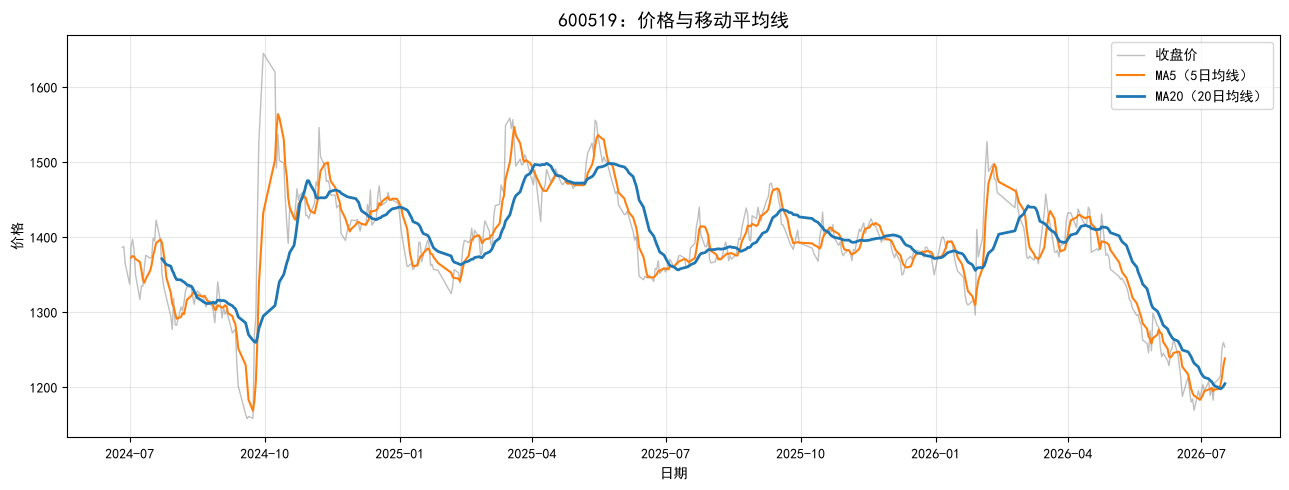

In [6]:
# ========== 画收盘价 + 两条均线 ==========
plt.figure(figsize=(13, 5))  # 创建画布
plt.plot(df.index, df['Close'], label='收盘价', color='gray', alpha=0.5, linewidth=1)  # 画折线图
plt.plot(df.index, df['MA5'], label='MA5（5日均线）', color='tab:orange', linewidth=1.5)  # 画折线图
plt.plot(df.index, df['MA20'], label='MA20（20日均线）', color='tab:blue', linewidth=2)  # 画折线图
plt.title(f'{TICKER}：价格与移动平均线', fontsize=14)  # 设置图标题
plt.xlabel('日期')  # 设置横轴标签
plt.ylabel('价格')  # 设置纵轴标签
plt.legend()  # 显示图例
plt.grid(True, alpha=0.3)  # 显示网格线
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('price_ma5_ma20.png', dpi=150, bbox_inches='tight')

plt.show()                               # 在 Notebook 里显示图片


In [7]:
# ========== 检测金叉、死叉 ==========
df['spread'] = df['MA5'] - df['MA20']              # 短均线减长均线
df['cross'] = np.sign(df['spread']).diff()         # 符号变化：正=金叉，负=死叉

golden = df[df['cross'] > 0].dropna(subset=['MA5', 'MA20'])  # 金叉那些天
death = df[df['cross'] < 0].dropna(subset=['MA5', 'MA20'])    # 死叉那些天

print(f'样本期内 金叉 {len(golden)} 次，死叉 {len(death)} 次')  # 打印统计结果
print('\n最近 3 次金叉日期：')  # 打印输出
print(golden.tail(3).index.strftime('%Y-%m-%d').tolist())  # 打印输出
print('\n最近 3 次死叉日期：')  # 打印输出
print(death.tail(3).index.strftime('%Y-%m-%d').tolist())  # 打印输出


样本期内 金叉 16 次，死叉 16 次

最近 3 次金叉日期：
['2026-03-18', '2026-04-01', '2026-07-14']

最近 3 次死叉日期：
['2026-03-03', '2026-03-25', '2026-04-21']


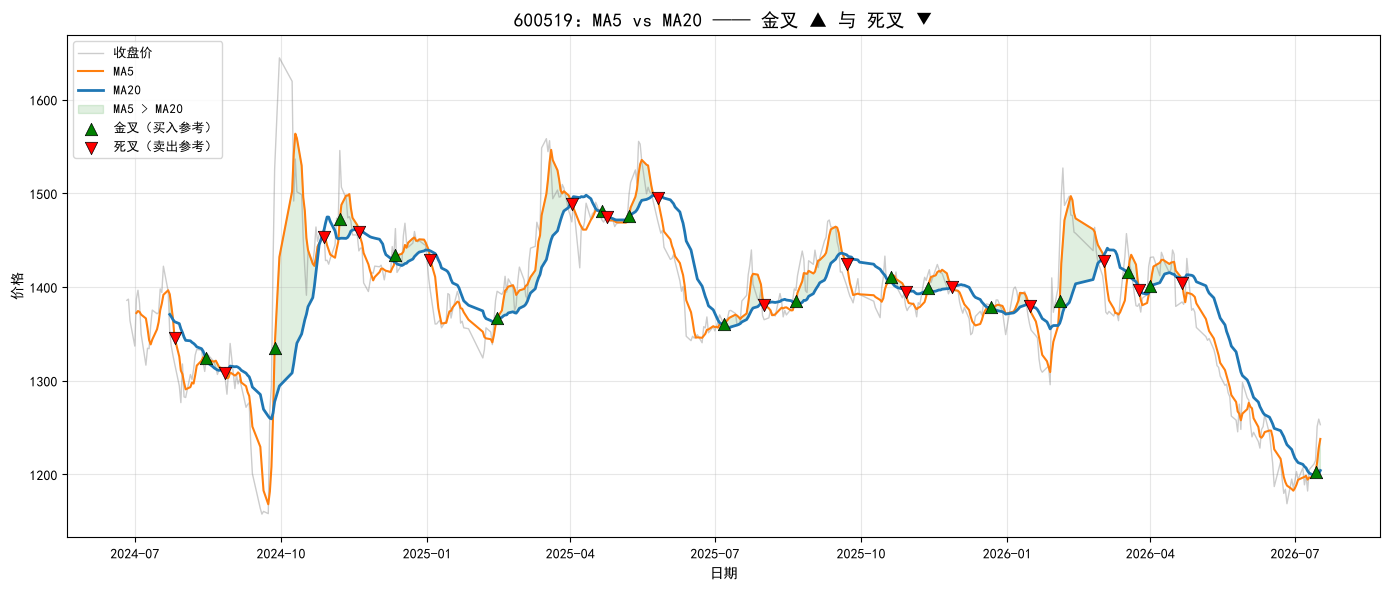

In [8]:
# ========== 金叉死叉标注图 ==========
fig, ax = plt.subplots(figsize=(14, 6))  # 创建子图

ax.plot(df.index, df['Close'], color='gray', alpha=0.4, linewidth=1, label='收盘价')  # 在子图上画折线
ax.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')  # 在子图上画折线
ax.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')  # 在子图上画折线

ax.fill_between(df.index, df['MA5'], df['MA20'],  # 在子图上填充区域
                where=(df['MA5'] >= df['MA20']),  # 计算 5 日移动平均线
                interpolate=True, alpha=0.12, color='green', label='MA5 > MA20')  # 填充区域平滑过渡

ax.scatter(golden.index, golden['MA5'], marker='^', s=80, color='green',  # 在子图上画散点
           edgecolors='black', linewidths=0.5, zorder=5, label='金叉（买入参考）')  # 图层顺序（点在线上方）
ax.scatter(death.index, death['MA5'], marker='v', s=80, color='red',  # 在子图上画散点
           edgecolors='black', linewidths=0.5, zorder=5, label='死叉（卖出参考）')  # 图层顺序（点在线上方）

ax.set_title(f'{TICKER}：MA5 vs MA20 —— 金叉 ▲ 与 死叉 ▼', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend(loc='upper left', fontsize=9)  # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('golden_death_cross.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [9]:
# ========== 第一个策略：MA5>MA20 则持仓 ==========
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 满足条件=1，否则=0

df['trade'] = 0                              # 默认无交易
df.loc[df['cross'] > 0, 'trade'] = 1         # 金叉日标记买入
df.loc[df['cross'] < 0, 'trade'] = -1        # 死叉日标记卖出

hold_days = df['signal'].sum()             # signal=1 的天数
print(f'规则：MA5 > MA20 则持仓 (signal=1)')  # 格式化打印
print(f'样本期内约 {hold_days} 个交易日处于持仓状态（共 {len(df)} 天）')  # 打印统计结果
print(f'共产生 { (df["trade"] != 0).sum() } 次调仓信号（买+卖）')  # 格式化打印

display(df[df['trade'] != 0][['Close', 'MA5', 'MA20', 'signal', 'trade']].tail(6))  # 在 Notebook 中美观显示表格

df[df['trade'] != 0][['Close', 'MA5', 'MA20', 'signal', 'trade']].to_csv('trade_signals.csv')

规则：MA5 > MA20 则持仓 (signal=1)
样本期内约 209 个交易日处于持仓状态（共 500 天）
共产生 32 次调仓信号（买+卖）


,Close,MA5,MA20,signal,trade
date,,,,,
2026-03-03,1398.17,1427.818,1434.6965,0,-1
2026-03-18,1440.78,1415.904,1414.1270,1,1
2026-03-25,1382.25,1396.688,1398.5695,0,-1
2026-04-01,1431.42,1401.308,1396.4660,1,1
2026-04-21,1383.99,1404.076,1409.6950,0,-1
2026-07-14,1214.88,1202.468,1197.2880,1,1


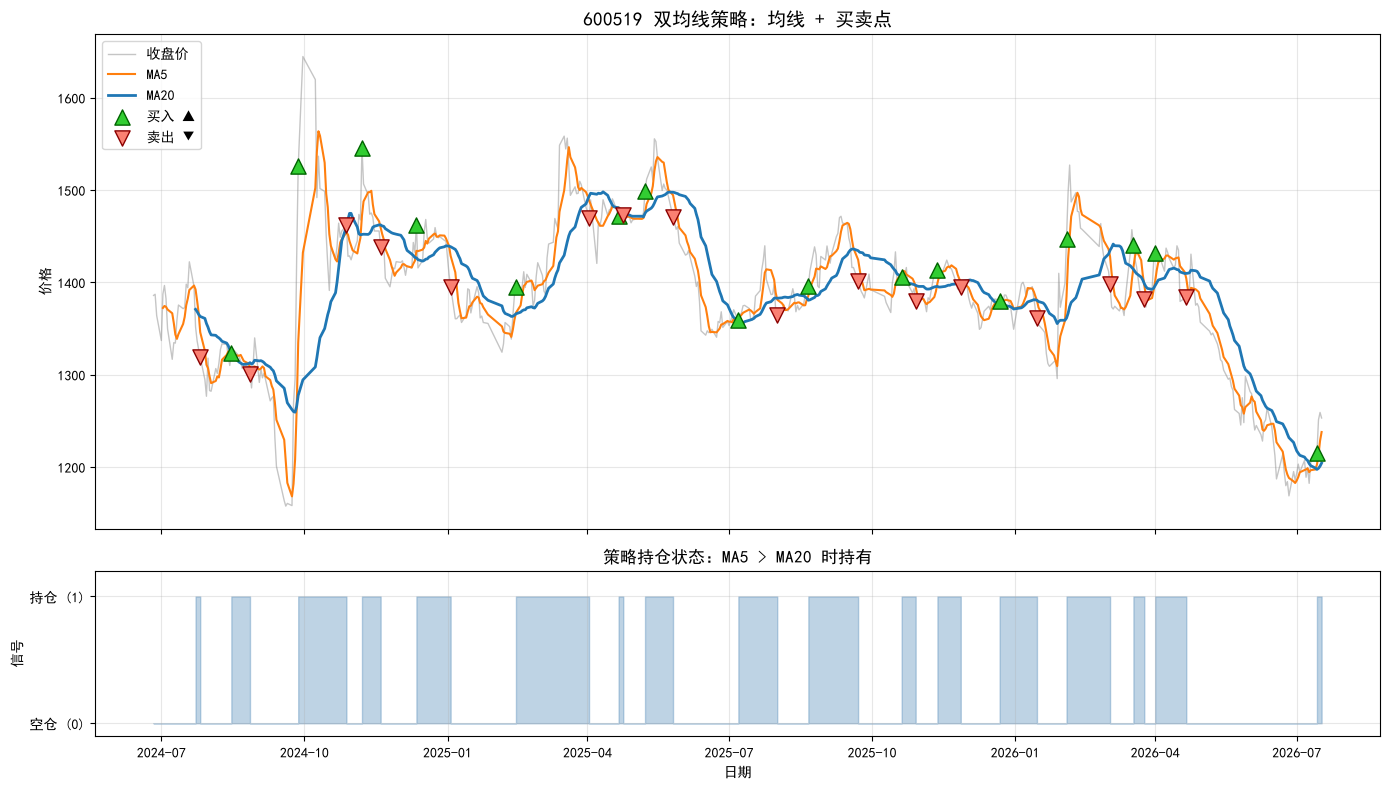

In [10]:
# ========== 策略信号大图：价格+买卖点+持仓条 ==========
buys = df[df['trade'] == 1]    # 所有买入日
sells = df[df['trade'] == -1]  # 所有卖出日

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,  # 创建子图
                         gridspec_kw={'height_ratios': [3, 1]})  # 子图高度比例
ax_price, ax_pos = axes  # 上图价格、下图持仓

ax_price.plot(df.index, df['Close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')  # 透明度
ax_price.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')  # 计算 5 日移动平均线
ax_price.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')  # 计算 20 日移动平均线

ax_price.scatter(buys.index, buys['Close'], marker='^', s=120, color='limegreen',  # 上三角标记（买入/金叉）
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')  # 散点边框颜色
ax_price.scatter(sells.index, sells['Close'], marker='v', s=120, color='salmon',  # 下三角标记（卖出/死叉）
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')  # 散点边框颜色

ax_price.set_title(f'{TICKER} 双均线策略：均线 + 买卖点', fontsize=14)  # 上图标题
ax_price.set_ylabel('价格')                                          # 上图纵轴：价格
ax_price.legend(loc='upper left')                                    # 显示图例
ax_price.grid(True, alpha=0.3)                                       # 显示网格

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')  # 策略信号：1=持仓，0=空仓
ax_pos.set_ylim(-0.1, 1.2)  # 执行本行代码
ax_pos.set_yticks([0, 1])  # 执行本行代码
ax_pos.set_yticklabels(['空仓 (0)', '持仓 (1)'])  # 执行本行代码
ax_pos.set_xlabel('日期')  # 执行本行代码
ax_pos.set_ylabel('信号')  # 执行本行代码
ax_pos.set_title('策略持仓状态：MA5 > MA20 时持有', fontsize=12)  # 字号
ax_pos.grid(True, alpha=0.3)  # 透明度

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('strategy_signals.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


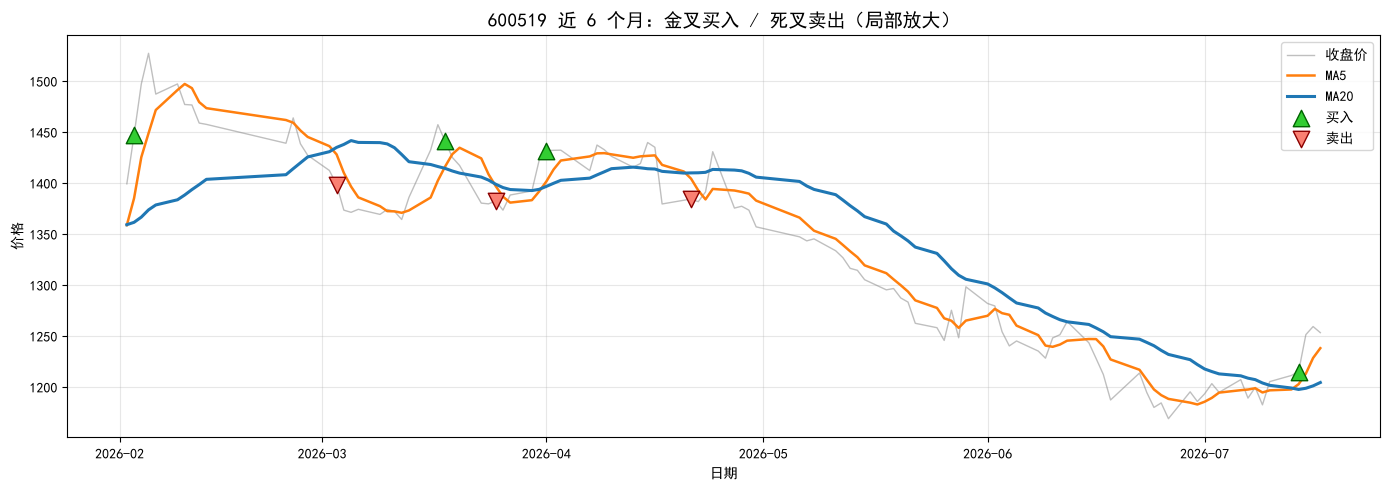

In [11]:
# ========== 放大最近6个月，看清买卖细节 ==========
recent = df.last('6M') if len(df) > 120 else df.tail(120)  # 取最近约6个月
buys_r = recent[recent['trade'] == 1]  # 最近区间的买入点
sells_r = recent[recent['trade'] == -1]  # 最近区间的卖出点

fig, ax = plt.subplots(figsize=(14, 5))  # 创建子图
ax.plot(recent.index, recent['Close'], color='gray', alpha=0.5, linewidth=1, label='收盘价')  # 在子图上画折线
ax.plot(recent.index, recent['MA5'], color='tab:orange', linewidth=1.8, label='MA5')  # 在子图上画折线
ax.plot(recent.index, recent['MA20'], color='tab:blue', linewidth=2.2, label='MA20')  # 在子图上画折线
ax.scatter(buys_r.index, buys_r['Close'], marker='^', s=140, color='limegreen',  # 在子图上画散点
           edgecolors='darkgreen', linewidths=1, zorder=6, label='买入')  # 散点边框颜色
ax.scatter(sells_r.index, sells_r['Close'], marker='v', s=140, color='salmon',  # 在子图上画散点
           edgecolors='darkred', linewidths=1, zorder=6, label='卖出')  # 散点边框颜色
ax.set_title(f'{TICKER} 近 6 个月：金叉买入 / 死叉卖出（局部放大）', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend()                                    # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('recent_6m_zoom.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [ ]:
修改TICKER ，截一张带 金叉▲ / 死叉▼ 的图——这就是你的第一张「策略信号图」。
试试 MA10 vs MA30，和 MA5/MA20 比：买卖次数变多了还是变少了？
思考题：金叉一定赚钱吗？为什么第四章要做回测？

In [12]:
# ========== 【大陆用户】用 AkShare 下载 A 股并计算 MA5、MA20 ==========
from datetime import datetime, timedelta  # 日期计算（起止日）

SYMBOL = '300750'   # A 股 6 位代码：600519 茅台、000001 平安银行、300750 宁德时代
DAYS = 500          # 约 2 年交易日，与上方 PERIOD='2y' 对应

# 6 位代码 → 腾讯/新浪格式（6 开头在上交所用 sh，其余用 sz）
market = 'sh' if SYMBOL.startswith('6') else 'sz'  # 判断上交所 sh 还是深交所 sz
code = f'{market}{SYMBOL}'  # 拼成腾讯/新浪需要的代码格式

end_date = datetime.now().strftime('%Y%m%d')  # 结束日期（今天）
start_date = (datetime.now() - timedelta(days=int(DAYS * 1.6))).strftime('%Y%m%d')  # 多取一些天，再 tail

# 东方财富接口常因限流断开，按稳定性依次尝试
sources = [  # 数据源列表（按稳定性排序）
    ('腾讯证券', lambda: ak.stock_zh_a_hist_tx(symbol=code, start_date=start_date, end_date=end_date, adjust='qfq')),  # 腾讯证券前复权日线
    ('新浪财经', lambda: ak.stock_zh_a_daily(symbol=code, start_date=start_date, end_date=end_date, adjust='qfq')),  # 新浪财经前复权日线
    ('东方财富', lambda: ak.stock_zh_a_hist(symbol=SYMBOL, period='daily', start_date=start_date, end_date=end_date, adjust='qfq')),  # 东方财富前复权日线
]                                              # 数组拼接结束
raw, last_err = None, None              # 初始化：原始数据、最后一次报错
for name, fetch in sources:  # 依次尝试各个数据源
    try:  # 尝试当前数据源
        raw = fetch()  # 下载原始行情
        print(f'数据来源：{name}')  # 格式化打印
        break                        # 成功拿到数据，跳出循环
    except Exception as e:  # 当前源失败则换下一个
        last_err = e  # 赋值：last_err
        print(f'{name} 暂不可用，尝试下一个…')  # 格式化打印
if raw is None:                               # 三个数据源都失败
    raise last_err  # 抛出错误

# 统一成 Close 列（不同接口列名略有差异）
raw = raw.copy()                              # 复制一份，避免改到原始表
if '收盘' in raw.columns:  # 东方财富接口的列名
    raw['日期'] = pd.to_datetime(raw['日期'])  # 转成日期时间格式
    df = raw.set_index('日期')[['收盘']].rename(columns={'收盘': 'Close'})  # 把某列设为行索引（日期）
elif 'close' in raw.columns:  # 腾讯/新浪接口的列名
    raw['date'] = pd.to_datetime(raw['date'])  # 转成日期时间格式
    df = raw.set_index('date')[['close']].rename(columns={'close': 'Close'})  # 把某列设为行索引（日期）
else:                              # 否则：本轮亏损
    raise ValueError('未识别的行情格式，请检查 akshare 版本')  # 抛出错误

df = pd.to_numeric(df['Close'], errors='coerce').to_frame().sort_index().dropna().tail(DAYS).copy()  # 删除空值行
df['MA5'] = df['Close'].rolling(5).mean()  # 滚动窗口计算
df['MA20'] = df['Close'].rolling(20).mean()  # 滚动窗口计算

TICKER = SYMBOL     # 后面图表标题会用到这个变量
print(f'{SYMBOL} 共 {len(df)} 个交易日')  # 打印统计结果
display(df.tail(8))  # 在 Notebook 中美观显示表格
df.to_csv('ndsd_ma_data.csv')


  0%|          | 0/3 [00:00<?, ?it/s]

数据来源：腾讯证券
300750 共 500 个交易日


,Close,MA5,MA20
date,,,
2026-07-08,361.00,374.070,388.8520
2026-07-09,375.50,372.700,388.2020
2026-07-10,348.76,366.452,386.5300
2026-07-13,359.06,363.362,384.7405
2026-07-14,364.01,361.666,383.0360
2026-07-15,373.00,364.066,381.5095
2026-07-16,366.20,362.206,379.8695
2026-07-17,360.00,364.454,378.2920


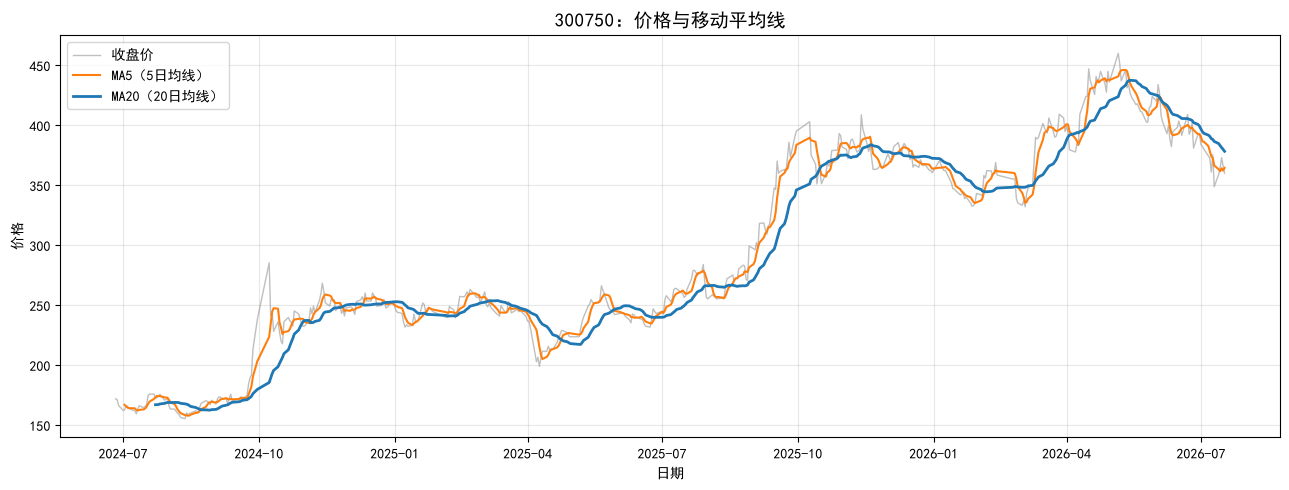

In [13]:
# ========== 画收盘价 + 两条均线 ==========
plt.figure(figsize=(13, 5))  # 创建画布
plt.plot(df.index, df['Close'], label='收盘价', color='gray', alpha=0.5, linewidth=1)  # 画折线图
plt.plot(df.index, df['MA5'], label='MA5（5日均线）', color='tab:orange', linewidth=1.5)  # 画折线图
plt.plot(df.index, df['MA20'], label='MA20（20日均线）', color='tab:blue', linewidth=2)  # 画折线图
plt.title(f'{TICKER}：价格与移动平均线', fontsize=14)  # 设置图标题
plt.xlabel('日期')  # 设置横轴标签
plt.ylabel('价格')  # 设置纵轴标签
plt.legend()  # 显示图例
plt.grid(True, alpha=0.3)  # 显示网格线
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('ndsd_price_ma5_ma20.png', dpi=150, bbox_inches='tight')

plt.show()                               # 在 Notebook 里显示图片


In [14]:
# ========== 检测金叉、死叉 ==========
df['spread'] = df['MA5'] - df['MA20']              # 短均线减长均线
df['cross'] = np.sign(df['spread']).diff()         # 符号变化：正=金叉，负=死叉

golden = df[df['cross'] > 0].dropna(subset=['MA5', 'MA20'])  # 金叉那些天
death = df[df['cross'] < 0].dropna(subset=['MA5', 'MA20'])    # 死叉那些天

print(f'样本期内 金叉 {len(golden)} 次，死叉 {len(death)} 次')  # 打印统计结果
print('\n最近 3 次金叉日期：')  # 打印输出
print(golden.tail(3).index.strftime('%Y-%m-%d').tolist())  # 打印输出
print('\n最近 3 次死叉日期：')  # 打印输出
print(death.tail(3).index.strftime('%Y-%m-%d').tolist())  # 打印输出


样本期内 金叉 13 次，死叉 14 次

最近 3 次金叉日期：
['2026-03-11', '2026-04-14', '2026-06-03']

最近 3 次死叉日期：
['2026-04-07', '2026-05-14', '2026-06-05']


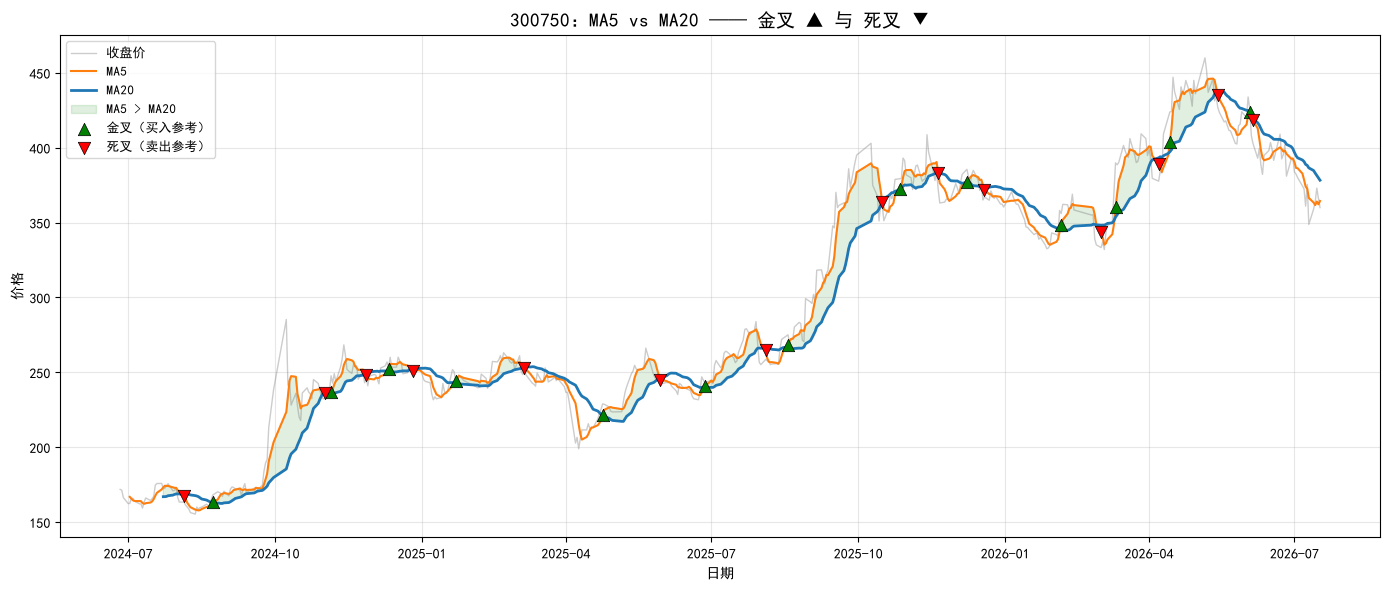

In [15]:
# ========== 金叉死叉标注图 ==========
fig, ax = plt.subplots(figsize=(14, 6))  # 创建子图

ax.plot(df.index, df['Close'], color='gray', alpha=0.4, linewidth=1, label='收盘价')  # 在子图上画折线
ax.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')  # 在子图上画折线
ax.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')  # 在子图上画折线

ax.fill_between(df.index, df['MA5'], df['MA20'],  # 在子图上填充区域
                where=(df['MA5'] >= df['MA20']),  # 计算 5 日移动平均线
                interpolate=True, alpha=0.12, color='green', label='MA5 > MA20')  # 填充区域平滑过渡

ax.scatter(golden.index, golden['MA5'], marker='^', s=80, color='green',  # 在子图上画散点
           edgecolors='black', linewidths=0.5, zorder=5, label='金叉（买入参考）')  # 图层顺序（点在线上方）
ax.scatter(death.index, death['MA5'], marker='v', s=80, color='red',  # 在子图上画散点
           edgecolors='black', linewidths=0.5, zorder=5, label='死叉（卖出参考）')  # 图层顺序（点在线上方）

ax.set_title(f'{TICKER}：MA5 vs MA20 —— 金叉 ▲ 与 死叉 ▼', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend(loc='upper left', fontsize=9)  # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('golden_death_cross.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [16]:
# ========== 第一个策略：MA5>MA20 则持仓 ==========
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 满足条件=1，否则=0

df['trade'] = 0                              # 默认无交易
df.loc[df['cross'] > 0, 'trade'] = 1         # 金叉日标记买入
df.loc[df['cross'] < 0, 'trade'] = -1        # 死叉日标记卖出

hold_days = df['signal'].sum()             # signal=1 的天数
print(f'规则：MA5 > MA20 则持仓 (signal=1)')  # 格式化打印
print(f'样本期内约 {hold_days} 个交易日处于持仓状态（共 {len(df)} 天）')  # 打印统计结果
print(f'共产生 { (df["trade"] != 0).sum() } 次调仓信号（买+卖）')  # 格式化打印

display(df[df['trade'] != 0][['Close', 'MA5', 'MA20', 'signal', 'trade']].tail(6))  # 在 Notebook 中美观显示表格

df[df['trade'] != 0][['Close', 'MA5', 'MA20', 'signal', 'trade']].to_csv('ndsd_trade_signals.csv')

规则：MA5 > MA20 则持仓 (signal=1)
样本期内约 267 个交易日处于持仓状态（共 500 天）
共产生 27 次调仓信号（买+卖）


,Close,MA5,MA20,signal,trade
date,,,,,
2026-03-11,389.89,360.214,353.6415,1,1
2026-04-07,377.68,389.016,393.2210,0,-1
2026-04-14,423.88,404.132,397.2815,1,1
2026-05-14,427.00,435.082,437.4680,0,-1
2026-06-03,426.42,424.018,423.1805,1,1
2026-06-05,403.00,418.322,419.3085,0,-1


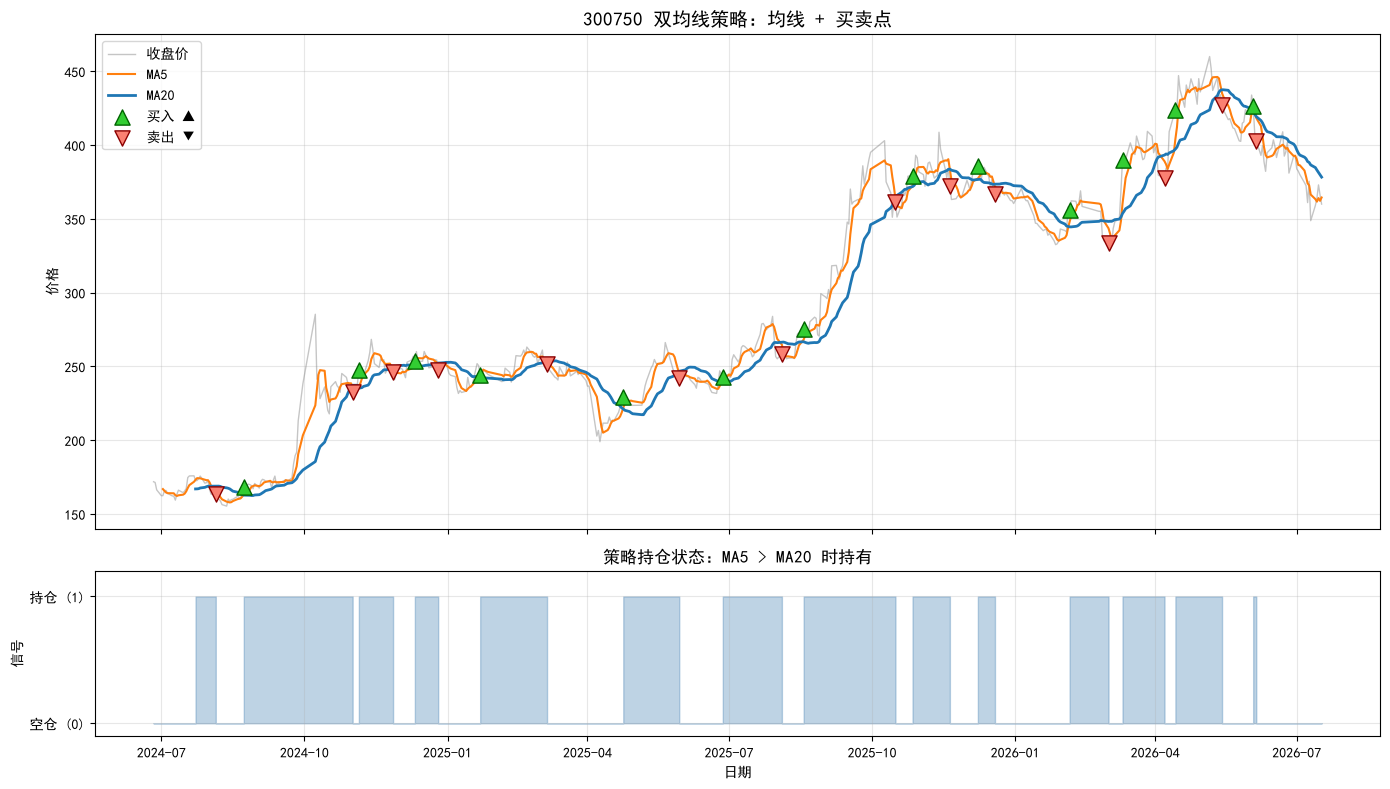

In [17]:
# ========== 策略信号大图：价格+买卖点+持仓条 ==========
buys = df[df['trade'] == 1]    # 所有买入日
sells = df[df['trade'] == -1]  # 所有卖出日

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,  # 创建子图
                         gridspec_kw={'height_ratios': [3, 1]})  # 子图高度比例
ax_price, ax_pos = axes  # 上图价格、下图持仓

ax_price.plot(df.index, df['Close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')  # 透明度
ax_price.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')  # 计算 5 日移动平均线
ax_price.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')  # 计算 20 日移动平均线

ax_price.scatter(buys.index, buys['Close'], marker='^', s=120, color='limegreen',  # 上三角标记（买入/金叉）
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')  # 散点边框颜色
ax_price.scatter(sells.index, sells['Close'], marker='v', s=120, color='salmon',  # 下三角标记（卖出/死叉）
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')  # 散点边框颜色

ax_price.set_title(f'{TICKER} 双均线策略：均线 + 买卖点', fontsize=14)  # 上图标题
ax_price.set_ylabel('价格')                                          # 上图纵轴：价格
ax_price.legend(loc='upper left')                                    # 显示图例
ax_price.grid(True, alpha=0.3)                                       # 显示网格

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')  # 策略信号：1=持仓，0=空仓
ax_pos.set_ylim(-0.1, 1.2)  # 执行本行代码
ax_pos.set_yticks([0, 1])  # 执行本行代码
ax_pos.set_yticklabels(['空仓 (0)', '持仓 (1)'])  # 执行本行代码
ax_pos.set_xlabel('日期')  # 执行本行代码
ax_pos.set_ylabel('信号')  # 执行本行代码
ax_pos.set_title('策略持仓状态：MA5 > MA20 时持有', fontsize=12)  # 字号
ax_pos.grid(True, alpha=0.3)  # 透明度

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切

plt.savefig('ndsd_strategy_signals.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


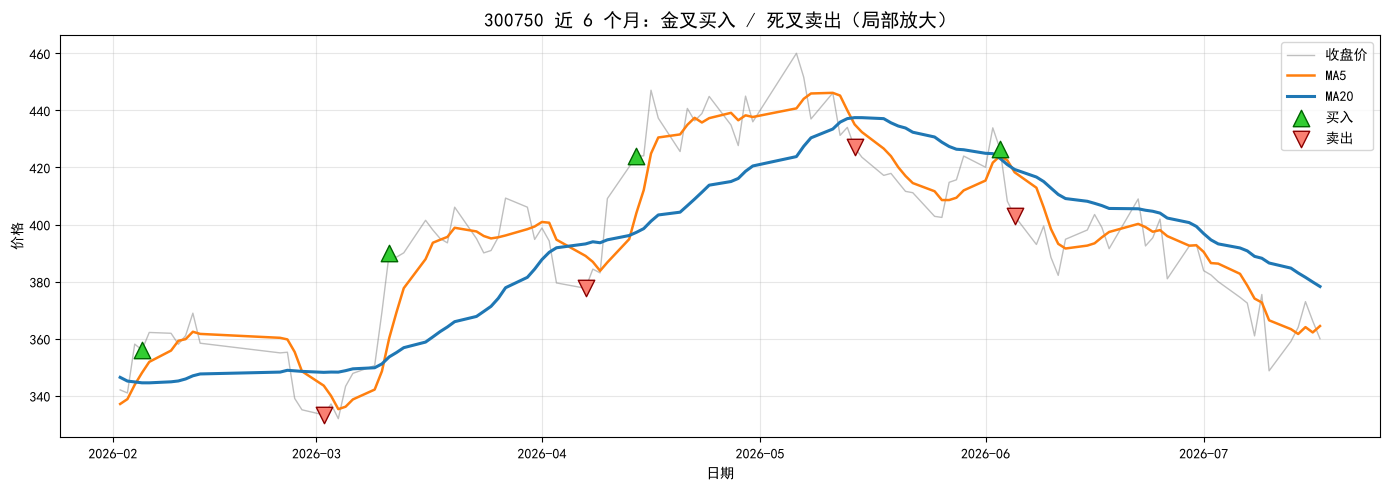

In [18]:
# ========== 放大最近6个月，看清买卖细节 ==========
recent = df.last('6M') if len(df) > 120 else df.tail(120)  # 取最近约6个月
buys_r = recent[recent['trade'] == 1]  # 最近区间的买入点
sells_r = recent[recent['trade'] == -1]  # 最近区间的卖出点

fig, ax = plt.subplots(figsize=(14, 5))  # 创建子图
ax.plot(recent.index, recent['Close'], color='gray', alpha=0.5, linewidth=1, label='收盘价')  # 在子图上画折线
ax.plot(recent.index, recent['MA5'], color='tab:orange', linewidth=1.8, label='MA5')  # 在子图上画折线
ax.plot(recent.index, recent['MA20'], color='tab:blue', linewidth=2.2, label='MA20')  # 在子图上画折线
ax.scatter(buys_r.index, buys_r['Close'], marker='^', s=140, color='limegreen',  # 在子图上画散点
           edgecolors='darkgreen', linewidths=1, zorder=6, label='买入')  # 散点边框颜色
ax.scatter(sells_r.index, sells_r['Close'], marker='v', s=140, color='salmon',  # 在子图上画散点
           edgecolors='darkred', linewidths=1, zorder=6, label='卖出')  # 散点边框颜色
ax.set_title(f'{TICKER} 近 6 个月：金叉买入 / 死叉卖出（局部放大）', fontsize=14)  # 设置子图标题
ax.set_xlabel('日期')  # 设置子图横轴
ax.set_ylabel('价格')  # 设置子图纵轴
ax.legend()                                    # 显示图例
ax.grid(True, alpha=0.3)  # 显示网格
plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.savefig('ndsd_recent_6m_zoom.png', dpi=150, bbox_inches='tight')
plt.show()                               # 在 Notebook 里显示图片


In [19]:
# ========== 挑战2：MA10 vs MA30，对比信号次数 ==========
df['MA10'] = df['Close'].rolling(10).mean()
df['MA30'] = df['Close'].rolling(30).mean()

df['spread_10_30'] = df['MA10'] - df['MA30']
df['cross_10_30'] = np.sign(df['spread_10_30']).diff()

golden_10_30 = df[df['cross_10_30'] > 0].dropna(subset=['MA10', 'MA30'])
death_10_30 = df[df['cross_10_30'] < 0].dropna(subset=['MA10', 'MA30'])

print(f'MA10/MA30：金叉 {len(golden_10_30)} 次，死叉 {len(death_10_30)} 次')
print(f'MA5/MA20：金叉 {len(golden)} 次，死叉 {len(death)} 次')

df.to_csv('challenge2_ma10_ma30_300750.csv')

MA10/MA30：金叉 9 次，死叉 10 次
MA5/MA20：金叉 13 次，死叉 14 次


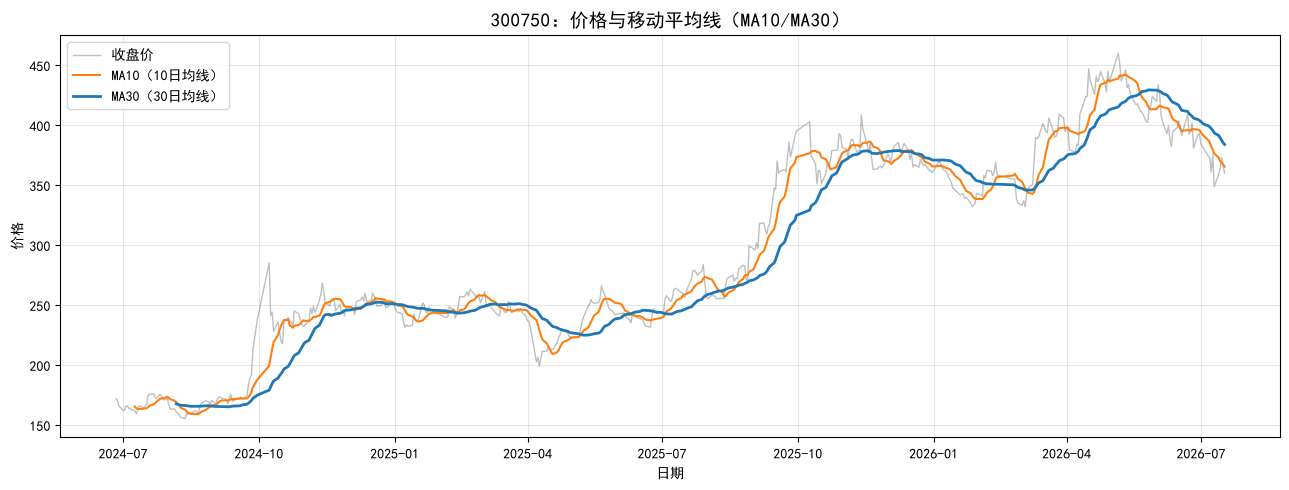

In [20]:
# ========== 画收盘价 + MA10 + MA30 ==========
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['Close'], label='收盘价', color='gray', alpha=0.5, linewidth=1)
plt.plot(df.index, df['MA10'], label='MA10（10日均线）', color='tab:orange', linewidth=1.5)
plt.plot(df.index, df['MA30'], label='MA30（30日均线）', color='tab:blue', linewidth=2)
plt.title(f'{TICKER}：价格与移动平均线（MA10/MA30）', fontsize=14)
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge2_price_ma10_ma30.png', dpi=150, bbox_inches='tight')
plt.show()

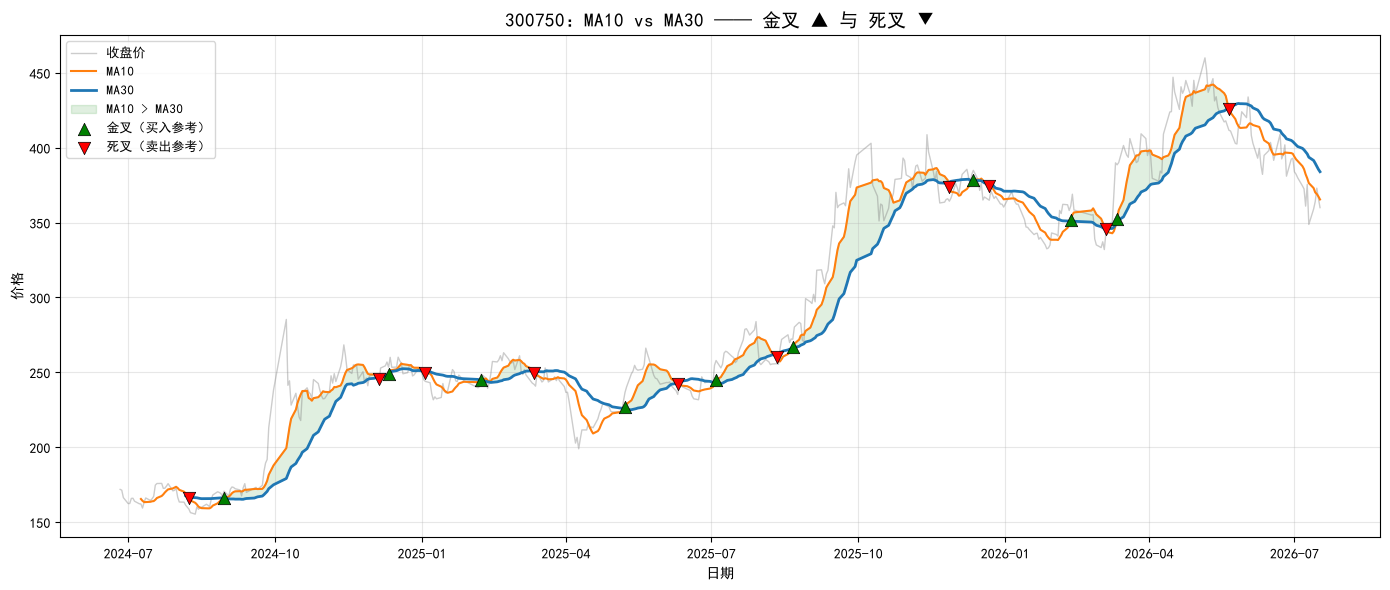

In [22]:

# ========== MA10/MA30 金叉死叉标注图 ==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], color='gray', alpha=0.4, linewidth=1, label='收盘价')
ax.plot(df.index, df['MA10'], color='tab:orange', linewidth=1.5, label='MA10')
ax.plot(df.index, df['MA30'], color='tab:blue', linewidth=2, label='MA30')

ax.fill_between(df.index, df['MA10'], df['MA30'],
                where=(df['MA10'] >= df['MA30']),
                interpolate=True, alpha=0.12, color='green', label='MA10 > MA30')

ax.scatter(golden_10_30.index, golden_10_30['MA10'], marker='^', s=80, color='green',
           edgecolors='black', linewidths=0.5, zorder=5, label='金叉（买入参考）')
ax.scatter(death_10_30.index, death_10_30['MA10'], marker='v', s=80, color='red',
           edgecolors='black', linewidths=0.5, zorder=5, label='死叉（卖出参考）')

ax.set_title(f'{TICKER}：MA10 vs MA30 —— 金叉 ▲ 与 死叉 ▼', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('challenge2_cross_ma10_ma30.png', dpi=150, bbox_inches='tight')
plt.show()

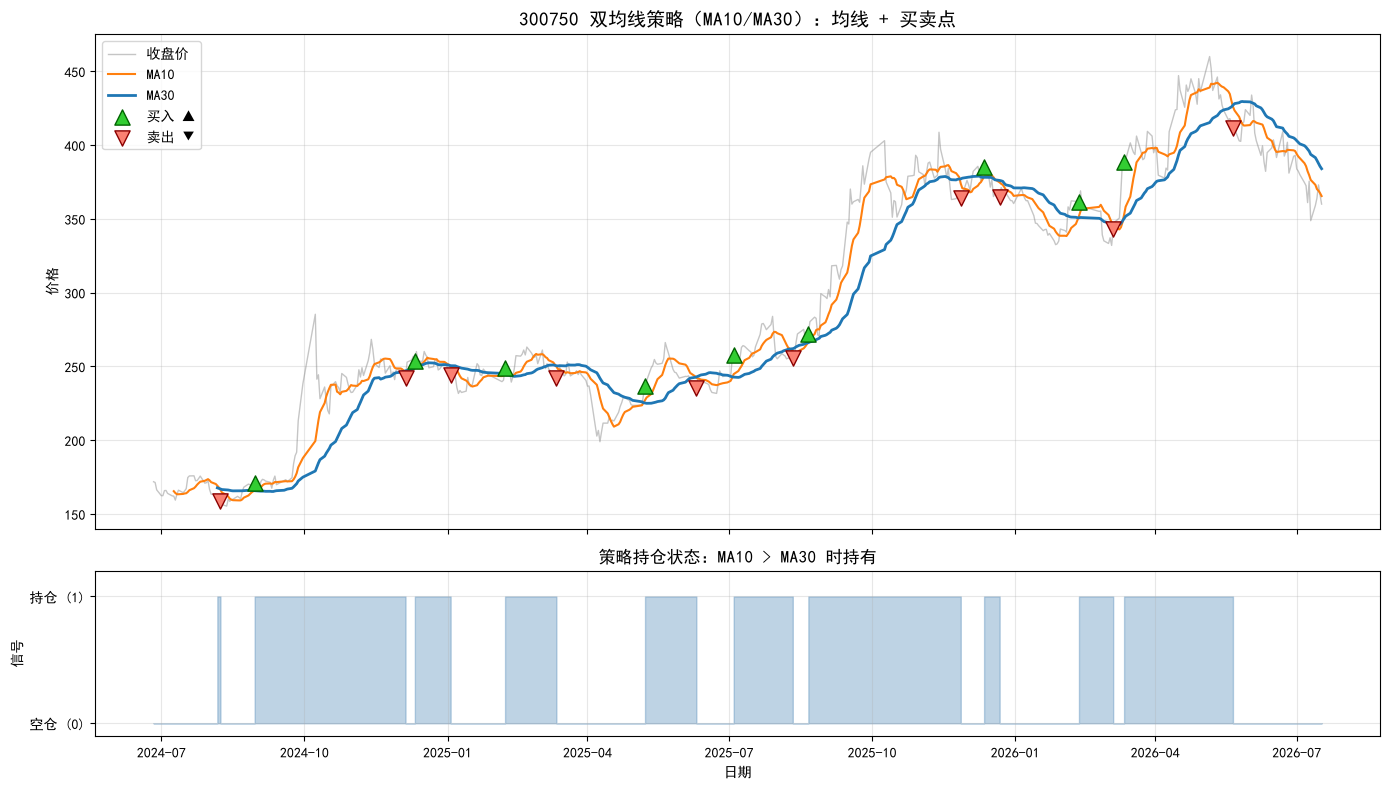

In [23]:

# ========== 生成 MA10/MA30 的 signal、trade ==========
df['signal_10_30'] = (df['MA10'] > df['MA30']).astype(int)
df['trade_10_30'] = 0
df.loc[df['cross_10_30'] > 0, 'trade_10_30'] = 1
df.loc[df['cross_10_30'] < 0, 'trade_10_30'] = -1

buys_10_30 = df[df['trade_10_30'] == 1]
sells_10_30 = df[df['trade_10_30'] == -1]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_pos = axes

ax_price.plot(df.index, df['Close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')
ax_price.plot(df.index, df['MA10'], color='tab:orange', linewidth=1.5, label='MA10')
ax_price.plot(df.index, df['MA30'], color='tab:blue', linewidth=2, label='MA30')

ax_price.scatter(buys_10_30.index, buys_10_30['Close'], marker='^', s=120, color='limegreen',
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')
ax_price.scatter(sells_10_30.index, sells_10_30['Close'], marker='v', s=120, color='salmon',
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')

ax_price.set_title(f'{TICKER} 双均线策略（MA10/MA30）：均线 + 买卖点', fontsize=14)
ax_price.set_ylabel('价格')
ax_price.legend(loc='upper left')
ax_price.grid(True, alpha=0.3)

ax_pos.fill_between(df.index, 0, df['signal_10_30'], step='post', alpha=0.35, color='steelblue')
ax_pos.set_ylim(-0.1, 1.2)
ax_pos.set_yticks([0, 1])
ax_pos.set_yticklabels(['空仓 (0)', '持仓 (1)'])
ax_pos.set_xlabel('日期')
ax_pos.set_ylabel('信号')
ax_pos.set_title('策略持仓状态：MA10 > MA30 时持有', fontsize=12)
ax_pos.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('challenge2_strategy_signals_ma10_ma30.png', dpi=150, bbox_inches='tight')
plt.show()
